# Test IV: Neural Operator Classification

This notebook compares the shared CNN baseline against the Fourier neural operator classifier.

The task is three-way classification over normalized strong-lensing fields with labels `no`, `sphere`, and `vort`. We inspect macro AUC, accuracy, per-class AUC, and the saved ROC, confusion, and learning-curve figures.

## Runtime Note

For a fuller benchmark, set `LIMIT_PER_CLASS = None` and optionally switch to a larger preset such as `highres`.

In [1]:
# %% Setup
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from neural_operator import ExperimentConfig, load_run_artifacts, run_suite, set_seed

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [2]:
# %% Configuration
DATA_ROOT = Path("dataset") / "dataset"
OUTPUT_ROOT = Path("runs") / "test_iv"
RUN_NAME = "neural_operator_demo"

SEED = 42
LIMIT_PER_CLASS = None

config = ExperimentConfig(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    backbone="both",
    preset="default",
    run_name=RUN_NAME,
    seed=SEED,
    tta="none",
    device=device,
    limit_per_class=LIMIT_PER_CLASS,
    verbose=False,
    log_to_file=True,
)

print(config)


ExperimentConfig(data_root=PosixPath('dataset/dataset'), output_root=PosixPath('runs/test_iv'), backbone='both', preset='default', run_name='neural_operator_demo', epochs=None, batch_size=None, learning_rate=None, image_size=None, disable_early_stopping=False, tta='none', seed=42, num_workers=0, device='cuda', limit_per_class=None, verbose=False, log_to_file=True)


In [3]:
# %% Run CNN/FNO comparison
set_seed(SEED)
summary = run_suite(config)
run_dir = Path(summary["run_dir"])
log_path = run_dir / "train.log"
split_summary = summary["split_summary"]

print(f"Run directory: {run_dir}")
print(f"Training log: {log_path}")
print(
    f"Split sizes: train={split_summary['train_size']}, val={split_summary['val_size']}, "
    f"per-class limit={LIMIT_PER_CLASS}"
)
print(f"Best backbone: {summary.get('best_backbone', summary['backbones'][0])}")

for backbone, metrics in summary["results"].items():
    print(
        f"{backbone.upper()}: macro_auc={metrics['macro_auc']:.4f}, "
        f"accuracy={metrics['accuracy']:.4f}, best_epoch={metrics['best_epoch']}"
    )


/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: 

Run directory: runs/test_iv/neural_operator_demo
Training log: runs/test_iv/neural_operator_demo/train.log
Split sizes: train=33750, val=3750, per-class limit=None
Best backbone: cnn
CNN: macro_auc=0.9845, accuracy=0.9189, best_epoch=16
FNO: macro_auc=0.9774, accuracy=0.8981, best_epoch=46


In [4]:
# %% Inspect saved metrics
artifacts = load_run_artifacts(run_dir)

for backbone, payload in artifacts["models"].items():
    metrics = payload["metrics"]
    print(
        f"{backbone.upper()}: macro_auc={metrics['macro_auc']:.4f}, "
        f"accuracy={metrics['accuracy']:.4f}, best_epoch={metrics['best_epoch']}, "
        f"params={metrics['num_parameters']}"
    )
    per_class_auc = metrics.get("per_class_auc") or {}
    per_class_text = ", ".join(
        f"{class_name}={auc:.4f}" if auc is not None else f"{class_name}=n/a"
        for class_name, auc in per_class_auc.items()
    )
    print(f"  per_class_auc: {per_class_text}")


CNN: macro_auc=0.9845, accuracy=0.9189, best_epoch=16, params=283635
  per_class_auc: no=0.9891, sphere=0.9785, vort=0.9859
FNO: macro_auc=0.9774, accuracy=0.8981, best_epoch=46, params=9489843
  per_class_auc: no=0.9849, sphere=0.9688, vort=0.9785


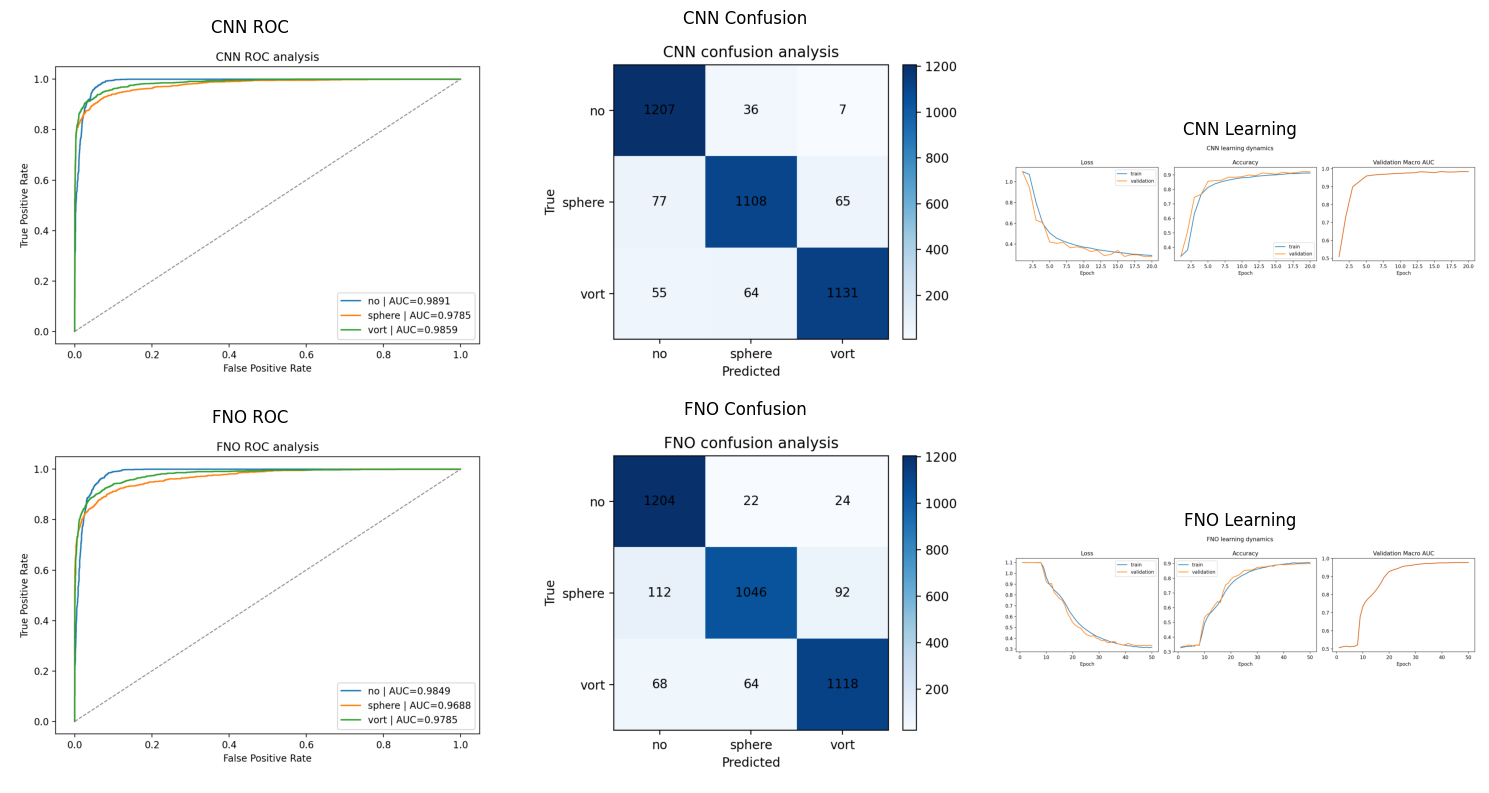

In [5]:
# %% Visualize saved figures
backbones = list(artifacts["models"].keys())
image_keys = [
    ("roc_curves", "ROC"),
    ("confusion_matrix", "Confusion"),
    ("training_curves", "Learning"),
]

fig, axes = plt.subplots(len(backbones), len(image_keys), figsize=(15, 4 * max(1, len(backbones))))
if len(backbones) == 1:
    axes = [axes]

for row_axes, backbone in zip(axes, backbones):
    for axis, (image_key, title) in zip(row_axes, image_keys):
        image_path = artifacts["models"][backbone]["paths"][image_key]
        if image_path.exists():
            axis.imshow(plt.imread(image_path))
            axis.set_title(f"{backbone.upper()} {title}")
        else:
            axis.set_title(f"{backbone.upper()} {title} missing")
        axis.axis("off")

plt.tight_layout()
plt.show()
